<a href="https://colab.research.google.com/github/NikosPatsamanis/X-Ray-classification/blob/main/X_Ray_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![z](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSJk_uHYGwlTQidgumwaK0DpHSoth_6uO3exg&s)

# **MSc in AI and Data Science (PT)**
##  X-Ray classification
### Assignment Part 1
### *Deadline:* 29/03/2026
### *Lesson:* Deep Learning
### *Name:* Nikolaos Patsamanis

Download MURA from Stanford University dataset site.

In [ ]:
!wget https://cs.stanford.edu/group/mlgroup/MURA-v1.1.zip

--2026-03-23 08:00:45--  https://cs.stanford.edu/group/mlgroup/MURA-v1.1.zip
Resolving cs.stanford.edu (cs.stanford.edu)... 171.64.64.64
Connecting to cs.stanford.edu (cs.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3380245855 (3.1G) [application/zip]
Saving to: ‘MURA-v1.1.zip’

MURA-v1.1.zip       100%[===================>]   3.15G  10.6MB/s    in 6m 43s  

2026-03-23 08:07:29 (8.01 MB/s) - ‘MURA-v1.1.zip’ saved [3380245855/3380245855]



Unzip

In [ ]:
!unzip -q MURA-v1.1.zip

Check that all folders exists

In [ ]:
import os

os.listdir('/content/MURA-v1.1/')

['valid_image_paths.csv',
 'valid',
 'valid_labeled_studies.csv',
 'train_image_paths.csv',
 'train_labeled_studies.csv',
 'train']

Install libraries

In [ ]:
!pip install torch torchvision

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

Image preprocessing

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

In [ ]:
import glob
from PIL import Image
from torch.utils.data import Dataset

class MURADataset(Dataset):

    def __init__(self, root, transform=None):
        self.paths = glob.glob(root + '/**/*.png', recursive=True)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        path = self.paths[idx]

        image = Image.open(path).convert("RGB")

        label = 1 if "positive" in path else 0

        if self.transform:
            image = self.transform(image)

        return image, label

Datasets creation

In [ ]:
train_dataset = MURADataset(
    "/content/MURA-v1.1/train",
    transform=transform
)

valid_dataset = MURADataset(
    "/content/MURA-v1.1/valid",
    transform=transform
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_loader = DataLoader(valid_dataset, batch_size=32)

Test

In [ ]:
img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 224, 224])
0


Plot random images

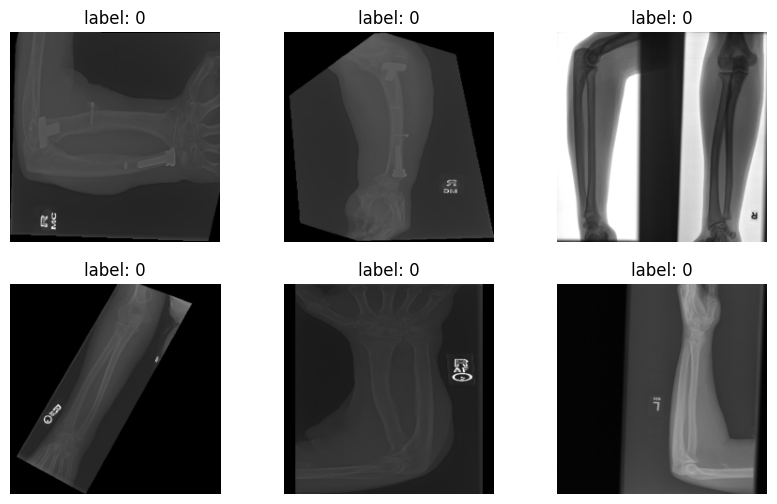

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,3, figsize=(10,6))

for i, ax in enumerate(axes.flat):

    img, label = train_dataset[i]

    ax.imshow(img.permute(1,2,0))
    ax.set_title("label: " + str(label))
    ax.axis("off")

plt.show()

## My CNN

CNN Baseline

Run Model with GPU (much quicker)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64*28*28,128), nn.ReLU(),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = BaselineCNN().to(device)

Loss and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training loop

In [ ]:
epochs = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):

    # Training
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs,1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs,1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(valid_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-"*40)

Epoch 1/5
Train Loss: 0.6600, Train Acc: 0.6035
Val Loss: 0.6738, Val Acc: 0.5696
----------------------------------------
Epoch 2/5
Train Loss: 0.6333, Train Acc: 0.6341
Val Loss: 0.6809, Val Acc: 0.5821
----------------------------------------
Epoch 3/5
Train Loss: 0.6020, Train Acc: 0.6678
Val Loss: 0.7058, Val Acc: 0.5934
----------------------------------------
Epoch 4/5
Train Loss: 0.5538, Train Acc: 0.7090
Val Loss: 0.7261, Val Acc: 0.5974
----------------------------------------
Epoch 5/5
Train Loss: 0.4720, Train Acc: 0.7668
Val Loss: 0.7948, Val Acc: 0.6109
----------------------------------------


Plot curves

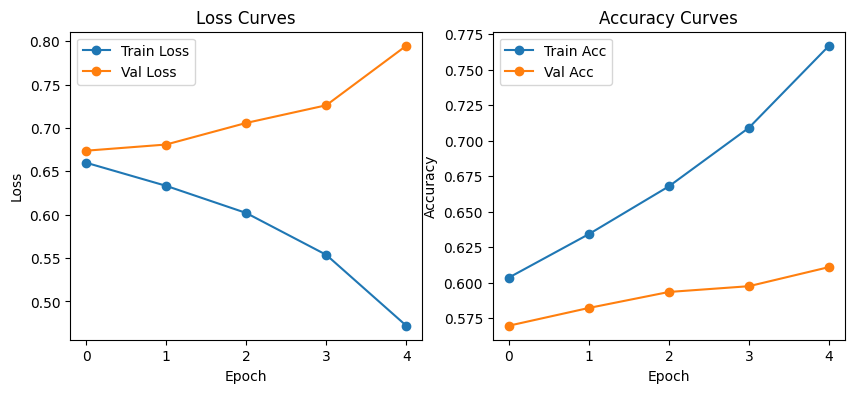

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc", marker='o')
plt.plot(val_accs, label="Val Acc", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()

There is overfitting. Model improves a lot at training data, but not at validation data.

I will generalize my model with Dropout (regularization), L2 weight decay (more regularization), Weighted CrossEntropyLoss (for imbalance of classes), Batch Normalization (for more stable training and better generalization), Early stopping (stop when validation loss is stable or start increasing).

Give bigger weight in the more rare class

In [ ]:
from collections import Counter
labels = [1 if "positive" in p else 0 for p in train_dataset.paths]
class_counts = Counter(labels)
weight_normal = 1.0 / class_counts[0]
weight_abnormal = 1.0 / class_counts[1]
weights = torch.tensor([weight_normal, weight_abnormal]).to(device)
print("Weights:", weights)

Weights: tensor([4.5589e-05, 6.7236e-05], device='cuda:0')


In [ ]:
class BaselineCNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(16,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64*28*28,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = BaselineCNN2().to(device)

Loss and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score

epochs = 20
patience = 3  # Early stopping if val_loss don't improve for 3 continuously epochs
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    train_f1 = f1_score(all_labels, all_preds)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    # Validation
    model.eval()
    running_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1} Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs,1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(valid_loader)
    val_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    val_f1 = f1_score(all_labels, all_preds)

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    print("-"*50)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1 Validation: 100%|██████████| 100/100 [00:19<00:00,  5.10it/s]


Epoch 1/20
Train Loss: 0.6933, Train Acc: 0.5567, Train F1: 0.2484
Val Loss: 0.6946, Val Acc: 0.5214, Val F1: 0.0000
--------------------------------------------------


Epoch 2 Validation: 100%|██████████| 100/100 [00:19<00:00,  5.19it/s]


Epoch 2/20
Train Loss: 0.6934, Train Acc: 0.5664, Train F1: 0.2262
Val Loss: 0.6936, Val Acc: 0.5214, Val F1: 0.0000
--------------------------------------------------


Epoch 3 Validation: 100%|██████████| 100/100 [00:20<00:00,  4.98it/s]


Epoch 3/20
Train Loss: 0.6938, Train Acc: 0.5655, Train F1: 0.2105
Val Loss: 0.6945, Val Acc: 0.5214, Val F1: 0.0000
--------------------------------------------------


Epoch 4 Validation: 100%|██████████| 100/100 [00:19<00:00,  5.03it/s]


Epoch 4/20
Train Loss: 0.6932, Train Acc: 0.5520, Train F1: 0.2920
Val Loss: 0.6947, Val Acc: 0.5214, Val F1: 0.0000
--------------------------------------------------


Epoch 5 Validation: 100%|██████████| 100/100 [00:19<00:00,  5.02it/s]

Epoch 5/20
Train Loss: 0.6932, Train Acc: 0.5462, Train F1: 0.3032
Val Loss: 0.6950, Val Acc: 0.5214, Val F1: 0.0000
--------------------------------------------------
Early stopping at epoch 5


Plot curves

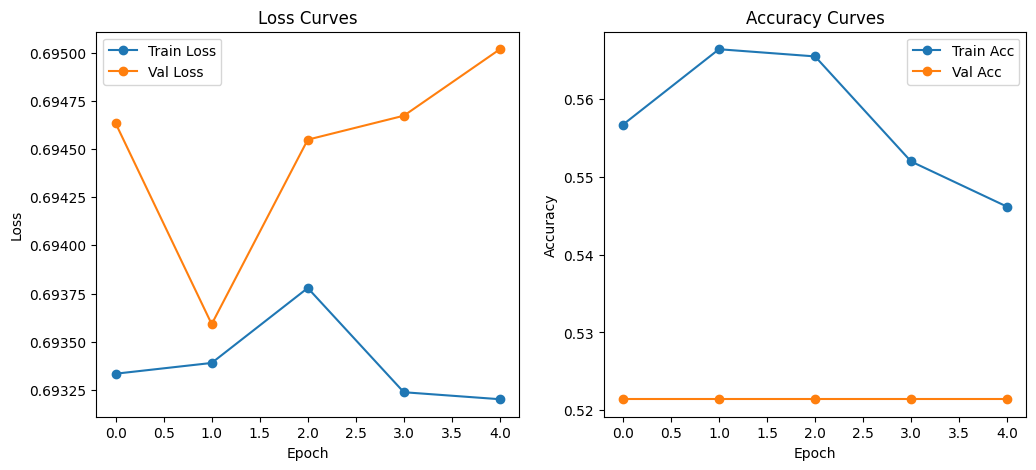

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc", marker='o')
plt.plot(val_accs, label="Val Acc", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()

I have Underfitting. I will decrease dropout and L2 weight decay.

In [ ]:
class BaselineCNN2_SoftReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),  # smaller dropout

            nn.Conv2d(16,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),  # smaller dropout

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)  # smaller dropout
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64*28*28,128),
            nn.ReLU(),
            nn.Dropout(0.3),  # smaller dropout
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = BaselineCNN2_SoftReg().to(device)

Loss and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-5)  # smaller L2

Epoch 1/20
Train Loss: 0.7475, Train Acc: 0.5479
Val Loss: 0.6952, Val Acc: 0.5214
--------------------------------------------------
Epoch 2/20
Train Loss: 0.6940, Train Acc: 0.5444
Val Loss: 0.6943, Val Acc: 0.5214
--------------------------------------------------
Epoch 3/20
Train Loss: 0.6939, Train Acc: 0.5596
Val Loss: 0.6924, Val Acc: 0.4786
--------------------------------------------------
Epoch 4/20
Train Loss: 0.6939, Train Acc: 0.5702
Val Loss: 0.6928, Val Acc: 0.4786
--------------------------------------------------
Epoch 5/20
Train Loss: 0.6936, Train Acc: 0.5706
Val Loss: 0.6933, Val Acc: 0.5214
--------------------------------------------------
Epoch 6/20
Train Loss: 0.6940, Train Acc: 0.5244
Val Loss: 0.6958, Val Acc: 0.5214
--------------------------------------------------
Early stopping at epoch 6


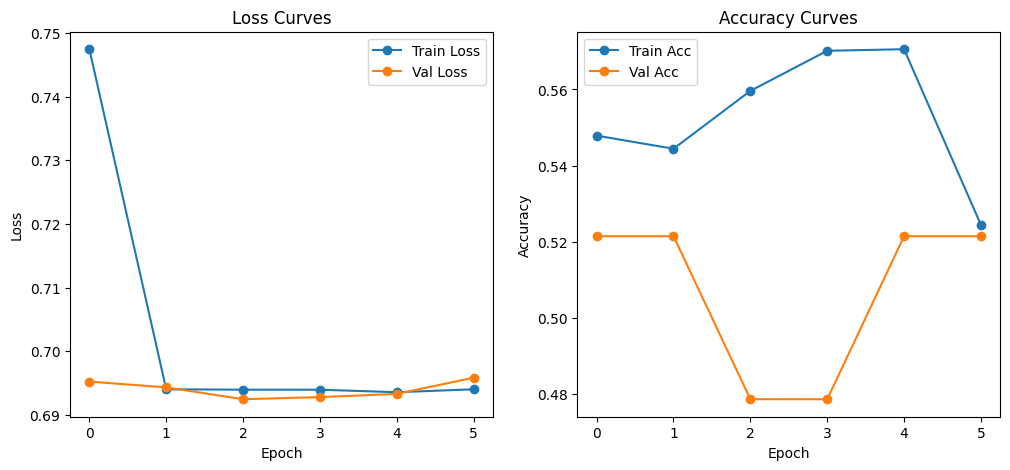

In [ ]:
epochs = 20
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs,1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs,1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(valid_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-"*50)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Plots
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc", marker='o')
plt.plot(val_accs, label="Val Acc", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()

I have Underfitting. I will add augmnentations for better generalization, smaller l2 and smaller dropout.

In [ ]:
import torchvision.transforms as transforms

# Small augmentations for better generalization
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # flip horizontally
    transforms.RandomRotation(10),           # flip +-10 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
import torch.nn as nn
import torch

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64*28*28,128), nn.ReLU(),
            nn.Dropout(0.3),  # smaller dropout
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN().to(device)

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)  # small L2

Epoch 1 Validation: 100%|██████████| 100/100 [00:19<00:00,  5.22it/s]


Epoch 1/20
Train Loss: 0.4542, Train Acc: 0.7720, Train F1: 0.7353
Val Loss: 0.8291, Val Acc: 0.6012, Val F1: 0.5867
--------------------------------------------------


Epoch 2 Validation: 100%|██████████| 100/100 [00:19<00:00,  5.23it/s]


Epoch 2/20
Train Loss: 0.3967, Train Acc: 0.8078, Train F1: 0.7747
Val Loss: 0.9761, Val Acc: 0.5987, Val F1: 0.5687
--------------------------------------------------


Epoch 3 Validation: 100%|██████████| 100/100 [00:18<00:00,  5.27it/s]


Epoch 3/20
Train Loss: 0.3446, Train Acc: 0.8358, Train F1: 0.8072
Val Loss: 1.1405, Val Acc: 0.5924, Val F1: 0.5397
--------------------------------------------------


Epoch 4 Validation: 100%|██████████| 100/100 [00:19<00:00,  5.18it/s]


Epoch 4/20
Train Loss: 0.3043, Train Acc: 0.8583, Train F1: 0.8329
Val Loss: 1.2127, Val Acc: 0.5993, Val F1: 0.5779
--------------------------------------------------
Early stopping at epoch 4


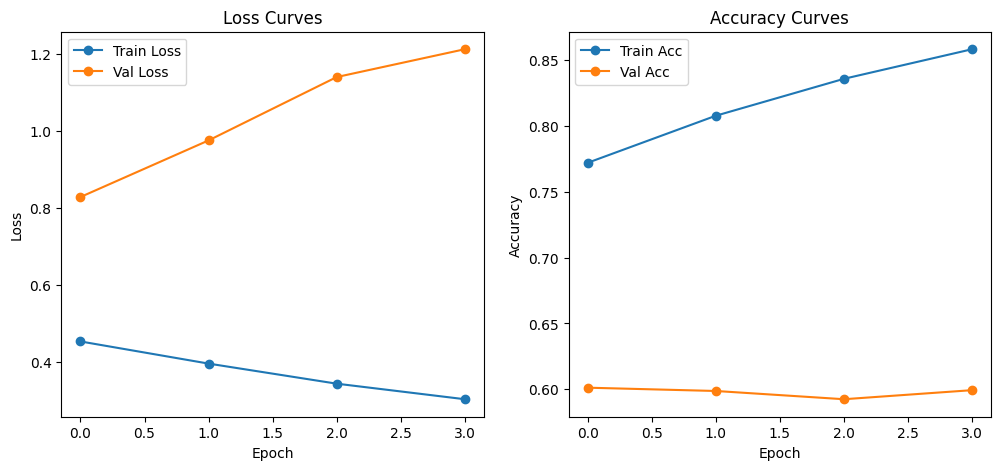

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from tqdm import tqdm

epochs = 20
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    train_f1 = f1_score(all_labels, all_preds, zero_division=0)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    # Validation
    model.eval()
    running_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1} Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs,1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(valid_loader)
    val_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    val_f1 = f1_score(all_labels, all_preds, zero_division=0)

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    print("-"*50)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc", marker='o')
plt.plot(val_accs, label="Val Acc", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.show()

I have overfitting. I will use stronger augmentations and bigger dropout.

In [ ]:
import torchvision.transforms as transforms

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # flip horizontally
    transforms.RandomRotation(20),              # +-20 degrees flip
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.ToTensor(),
])

transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
import torch.nn as nn
import torch

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64*28*28,128), nn.ReLU(),
            nn.Dropout(0.5),  # bigger dropout for better generalization
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN().to(device)

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

In [ ]:
from collections import Counter
import torch

labels = [1 if "positive" in p else 0 for p in train_dataset.paths]
class_counts = Counter(labels)

weight_normal = 1.0 / class_counts[0]
weight_abnormal = 1.0 / class_counts[1]

weights = torch.tensor([weight_normal, weight_abnormal]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

Epoch 1 Validation: 100%|██████████| 100/100 [00:22<00:00,  4.41it/s]


Epoch 1/20
Train Loss: 0.6802, Train Acc: 0.5678, Train F1: 0.5125
Val Loss: 0.6793, Val Acc: 0.5805, Val F1: 0.5150
--------------------------------------------------


Epoch 2 Validation: 100%|██████████| 100/100 [00:20<00:00,  4.98it/s]


Epoch 2/20
Train Loss: 0.6635, Train Acc: 0.6016, Train F1: 0.5451
Val Loss: 0.6843, Val Acc: 0.5918, Val F1: 0.4663
--------------------------------------------------


Epoch 3 Validation: 100%|██████████| 100/100 [00:20<00:00,  4.94it/s]


...

Epoch 8/20
Train Loss: 0.5819, Train Acc: 0.6896, Train F1: 0.6331
Val Loss: 0.6535, Val Acc: 0.6318, Val F1: 0.5734
--------------------------------------------------


Epoch 9 Validation: 100%|██████████| 100/100 [00:20<00:00,  4.98it/s]


Epoch 9/20
Train Loss: 0.5650, Train Acc: 0.7043, Train F1: 0.6490
Val Loss: 0.6403, Val Acc: 0.6431, Val F1: 0.6203
--------------------------------------------------


Epoch 10 Validation: 100%|██████████| 100/100 [00:20<00:00,  4.99it/s]


Epoch 10/20
Train Loss: 0.5526, Train Acc: 0.7123, Train F1: 0.6592
Val Loss: 0.6402, Val Acc: 0.6440, Val F1: 0.6174
--------------------------------------------------
Early stopping at epoch 10


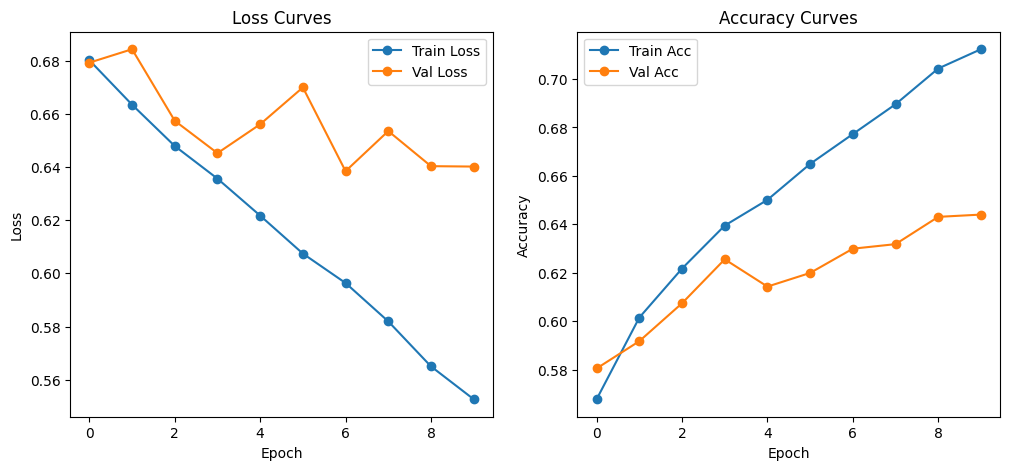

In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

epochs = 20
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    train_f1 = f1_score(all_labels, all_preds, zero_division=0)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    # Validation
    model.eval()
    running_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1} Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs,1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(valid_loader)
    val_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    val_f1 = f1_score(all_labels, all_preds, zero_division=0)

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    print("-"*50)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc", marker='o')
plt.plot(val_accs, label="Val Acc", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.show()

There is a small overfit but it is not big enough to annoy. It seems that augmentations helped a lot. Also, has Accuracy score close to F1, indicates that the model does not ignore the minority class.

## Pre-trained CNN

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze convolutional layers
for param in model.parameters():
    param.requires_grad = False

# Replace last layer
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 75.6MB/s]


In [ ]:
from collections import Counter
import torch

labels = [1 if "positive" in p else 0 for p in train_dataset.paths]
class_counts = Counter(labels)

weights = torch.tensor([
    1.0 / class_counts[0],
    1.0 / class_counts[1]
]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

epochs = 10
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(epochs):

    # Training
    model.train()
    running_loss = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    train_f1 = f1_score(all_labels, all_preds, zero_division=0)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    # Validation
    model.eval()
    running_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1} Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs,1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(valid_loader)
    val_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    val_f1 = f1_score(all_labels, all_preds, zero_division=0)

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    print("-"*50)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1 Validation: 100%|██████████| 100/100 [00:22<00:00,  4.36it/s]


Epoch 1/10
Train Loss: 0.6452, Train Acc: 0.6215, Train F1: 0.5718
Val Loss: 0.6394, Val Acc: 0.6641, Val F1: 0.6013
--------------------------------------------------


Epoch 2 Validation: 100%|██████████| 100/100 [00:22<00:00,  4.41it/s]


Epoch 2/10
Train Loss: 0.6079, Train Acc: 0.6678, Train F1: 0.6160
Val Loss: 0.6032, Val Acc: 0.6600, Val F1: 0.6596
--------------------------------------------------


Epoch 3 Validation: 100%|██████████| 100/100 [00:22<00:00,  4.44it/s]


...

Epoch 8/10
Train Loss: 0.5673, Train Acc: 0.7087, Train F1: 0.6510
Val Loss: 0.5660, Val Acc: 0.6869, Val F1: 0.6904
--------------------------------------------------


Epoch 9 Validation: 100%|██████████| 100/100 [00:22<00:00,  4.41it/s]


Epoch 9/10
Train Loss: 0.5621, Train Acc: 0.7156, Train F1: 0.6583
Val Loss: 0.5708, Val Acc: 0.6963, Val F1: 0.6741
--------------------------------------------------


Epoch 10 Validation: 100%|██████████| 100/100 [00:23<00:00,  4.33it/s]

Epoch 10/10
Train Loss: 0.5619, Train Acc: 0.7159, Train F1: 0.6583
Val Loss: 0.5668, Val Acc: 0.6994, Val F1: 0.6827
--------------------------------------------------


Plot curves

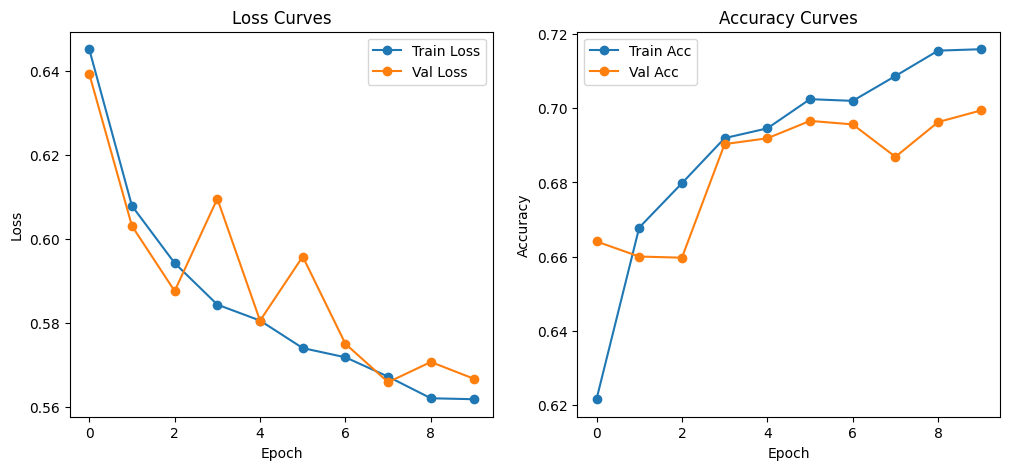

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc", marker='o')
plt.plot(val_accs, label="Val Acc", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()

There are training accuracy and validation accuracy very close to each other, so there is no overfitting. Accuracy is increasing and loss is decreasing, so i have a stable training.